# 23CSE301 Machine Learning - Capstone Project

## Classification Track - Part A

### Bank Marketing Dataset

**Algorithms:**
1. Logistic Regression
2. K-Nearest Neighbors
3. Gaussian Naive Bayes
4. Decision Tree Classifier
5. Support Vector Machine

---

### Problem Statement
The objective of this classification project is to predict whether a bank customer will subscribe to a term deposit (binary target variable `y`: `yes` or `no`) based on direct telemarketing campaign data from a Portuguese banking institution. The dataset encompasses client demographics, financial indicators, past contact interactions, and macroeconomic attributes. Accurately predicting customer subscription propensity enables the institution to optimize marketing resource allocation, target high-probability prospective clients, and improve campaign efficiency.

In accordance with the 23CSE301 Capstone Project Guidelines, this notebook implements Part A of the Classification Track, covering the five core algorithms evaluated in Review 1. All models are trained and tested on an identical stratified split with strict prevention of data leakage.


## 2. Import Required Libraries

This section imports the necessary libraries for data processing, exploratory data analysis, pipeline creation, model training, hyperparameter tuning, and performance evaluation.

A fixed random seed (`RANDOM_STATE = 42`) is established to guarantee reproducibility across all data splits and randomized estimators.


In [1]:
# Import display explicitly to prevent callable conflict
from IPython.display import display

# Core data manipulation and numerical libraries
import os
import numpy as np
import pandas as pd

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn model selection and validation
from sklearn.model_selection import train_test_split, GridSearchCV

# Scikit-learn preprocessing and pipeline utilities
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Scikit-learn classification algorithms (Part A)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC

# Scikit-learn evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

# Plot formatting and styling
sns.set_theme(style="whitegrid", palette="tab10")
plt.rcParams["figure.autolayout"] = True

# Deterministic random seed
RANDOM_STATE = 42


## 3. Load Dataset

Loading the Bank Marketing dataset (`bank-full.csv`). The file uses semicolon delimiters (`sep=";"`). The path is verified to ensure robust loading whether executed from the project root or the notebooks directory.


In [2]:
# Locate bank-full.csv (checking current directory and common relative data paths)
csv_filename = "bank-full.csv"
if os.path.exists(csv_filename):
    csv_path = csv_filename
elif os.path.exists(os.path.join("data", csv_filename)):
    csv_path = os.path.join("data", csv_filename)
elif os.path.exists(os.path.join("..", "data", csv_filename)):
    csv_path = os.path.join("..", "data", csv_filename)
else:
    csv_path = csv_filename

df = pd.read_csv(csv_path, sep=";")
print(f"Dataset successfully loaded from: {csv_path}")


Dataset successfully loaded from: ..\data\bank-full.csv


In [3]:
# Display first 5 rows
print("--- First 5 Rows ---")
display(df.head())

# Display last 5 rows
print("--- Last 5 Rows ---")
display(df.tail())

# Dataset shape
print(f"\nDataset Dimensions: {df.shape[0]} rows, {df.shape[1]} columns")

# Column names and data types
print("\n--- Column Names & Data Types ---")
display(df.dtypes.to_frame(name="Data Type"))

# DataFrame info
print("\n--- DataFrame Information ---")
df.info()


--- First 5 Rows ---


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


--- Last 5 Rows ---


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
4516,33,services,married,secondary,no,-333,yes,no,cellular,30,jul,329,5,-1,0,unknown,no
4517,57,self-employed,married,tertiary,yes,-3313,yes,yes,unknown,9,may,153,1,-1,0,unknown,no
4518,57,technician,married,secondary,no,295,no,no,cellular,19,aug,151,11,-1,0,unknown,no
4519,28,blue-collar,married,secondary,no,1137,no,no,cellular,6,feb,129,4,211,3,other,no
4520,44,entrepreneur,single,tertiary,no,1136,yes,yes,cellular,3,apr,345,2,249,7,other,no



Dataset Dimensions: 4521 rows, 17 columns

--- Column Names & Data Types ---


,Data Type
age,int64
job,object
marital,object
education,object
default,object
balance,int64
housing,object
loan,object
contact,object
day,int64



--- DataFrame Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        4521 non-null   int64 
 1   job        4521 non-null   object
 2   marital    4521 non-null   object
 3   education  4521 non-null   object
 4   default    4521 non-null   object
 5   balance    4521 non-null   int64 
 6   housing    4521 non-null   object
 7   loan       4521 non-null   object
 8   contact    4521 non-null   object
 9   day        4521 non-null   int64 
 10  month      4521 non-null   object
 11  duration   4521 non-null   int64 
 12  campaign   4521 non-null   int64 
 13  pdays      4521 non-null   int64 
 14  previous   4521 non-null   int64 
 15  poutcome   4521 non-null   object
 16  y          4521 non-null   object
dtypes: int64(7), object(10)
memory usage: 600.6+ KB


## 4. Dataset Audit

A rigorous dataset audit assesses data hygiene prior to model construction:
- Verification of missing values (`NaN` / `null`)
- Detection of duplicate records
- Examination of numerical feature distributions and ranges
- Examination of categorical unique value counts and cardinality
- Identification and enumeration of implicit missing values recorded as `"unknown"`


In [4]:
# Missing values audit
missing_counts = df.isnull().sum()
missing_pct = (missing_counts / len(df)) * 100
missing_df = pd.DataFrame({"Missing Count": missing_counts, "Percentage (%)": missing_pct})
print("--- Missing Values Audit ---")
display(missing_df)

# Duplicate records audit
duplicate_count = df.duplicated().sum()
print(f"\nDuplicate Rows Detected: {duplicate_count}")


--- Missing Values Audit ---


,Missing Count,Percentage (%)
age,0,0.0
job,0,0.0
marital,0,0.0
education,0,0.0
default,0,0.0
balance,0,0.0
housing,0,0.0
loan,0,0.0
contact,0,0.0
day,0,0.0



Duplicate Rows Detected: 0


In [5]:
# Statistical summary of numerical features
print("--- Numerical Features Statistical Summary ---")
display(df.describe().T)

# Statistical summary of categorical features
print("\n--- Categorical Features Statistical Summary ---")
display(df.describe(include=["object"]).T)


--- Numerical Features Statistical Summary ---


,count,mean,std,min,25%,50%,75%,max
age,4521.0,41.170095,10.576211,19.0,33.0,39.0,49.0,87.0
balance,4521.0,1422.657819,3009.638142,-3313.0,69.0,444.0,1480.0,71188.0
day,4521.0,15.915284,8.247667,1.0,9.0,16.0,21.0,31.0
duration,4521.0,263.961292,259.856633,4.0,104.0,185.0,329.0,3025.0
campaign,4521.0,2.793630,3.109807,1.0,1.0,2.0,3.0,50.0
pdays,4521.0,39.766645,100.121124,-1.0,-1.0,-1.0,-1.0,871.0
previous,4521.0,0.542579,1.693562,0.0,0.0,0.0,0.0,25.0



--- Categorical Features Statistical Summary ---


,count,unique,top,freq
job,4521,12,management,969
marital,4521,3,married,2797
education,4521,4,secondary,2306
default,4521,2,no,4445
housing,4521,2,yes,2559
loan,4521,2,no,3830
contact,4521,3,cellular,2896
month,4521,12,may,1398
poutcome,4521,4,unknown,3705
y,4521,2,no,4000


In [6]:
# Categorical unique values audit
print("--- Categorical Unique Values ---")
cat_cols = df.select_dtypes(include=["object"]).columns
for col in cat_cols:
    print(f"Column '{col}' ({df[col].nunique()} unique): {df[col].unique().tolist()[:8]}")

# Audit 'unknown' values across columns
unknown_counts = (df == "unknown").sum()
unknown_df = pd.DataFrame({
    "Unknown Count": unknown_counts[unknown_counts > 0],
    "Percentage (%)": ((unknown_counts[unknown_counts > 0] / len(df)) * 100).round(2)
})
print("\n--- Implicit Missing Values ('unknown') Audit ---")
display(unknown_df)


--- Categorical Unique Values ---
Column 'job' (12 unique): ['unemployed', 'services', 'management', 'blue-collar', 'self-employed', 'technician', 'entrepreneur', 'admin.']
Column 'marital' (3 unique): ['married', 'single', 'divorced']
Column 'education' (4 unique): ['primary', 'secondary', 'tertiary', 'unknown']
Column 'default' (2 unique): ['no', 'yes']
Column 'housing' (2 unique): ['no', 'yes']
Column 'loan' (2 unique): ['no', 'yes']
Column 'contact' (3 unique): ['cellular', 'unknown', 'telephone']
Column 'month' (12 unique): ['oct', 'may', 'apr', 'jun', 'feb', 'aug', 'jan', 'jul']
Column 'poutcome' (4 unique): ['unknown', 'failure', 'other', 'success']
Column 'y' (2 unique): ['no', 'yes']

--- Implicit Missing Values ('unknown') Audit ---


,Unknown Count,Percentage (%)
job,38,0.84
education,187,4.14
contact,1324,29.29
poutcome,3705,81.95


> **Technical Note on `"unknown"` Values**: 
> `"unknown"` indicates non-disclosed or uncollected customer responses (e.g., in contact method, education, or poutcome). Removing these rows would eliminate substantial training data and introduce non-random attrition bias. Therefore, `"unknown"` is preserved as an informative category level for encoding.


## 5. Exploratory Data Analysis (EDA)

In alignment with the official rubric, the exploratory data analysis includes:
1. **Target distribution** (counts and proportions)
2. **Numerical feature distributions**
3. **Categorical feature distributions**
4. **Correlation heatmap** for continuous features
5. **Bivariate scatter plots** exploring relationships between features and the target variable


### 5.1 Target Variable Distribution (`y`)
Visualizing the distribution of the binary target variable `y`.


C:\Users\sanja\AppData\Local\Temp\ipykernel_5412\3652684653.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="y", ax=axes[0], palette="tab10", order=["no", "yes"])


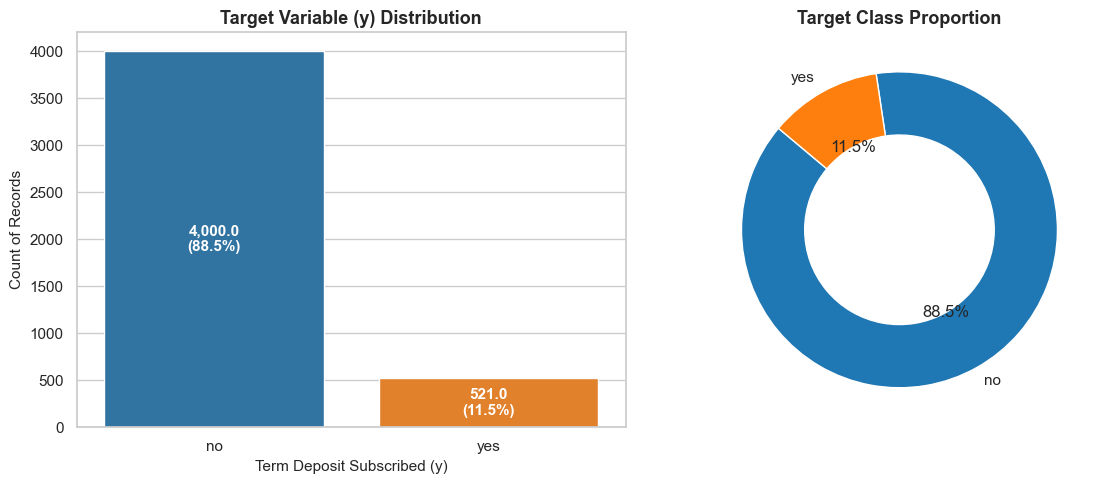

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Target count plot
sns.countplot(data=df, x="y", ax=axes[0], palette="tab10", order=["no", "yes"])
axes[0].set_title("Target Variable (y) Distribution", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Term Deposit Subscribed (y)", fontsize=11)
axes[0].set_ylabel("Count of Records", fontsize=11)

# Annotate counts and percentages
total_records = len(df)
for p in axes[0].patches:
    h = p.get_height()
    axes[0].annotate(f"{h:,}\n({(h/total_records)*100:.1f}%)",
                     (p.get_x() + p.get_width() / 2., h / 2),
                     ha="center", va="center", fontsize=11, color="white", fontweight="bold")

# Target proportion donut chart
y_counts = df["y"].value_counts()
axes[1].pie(y_counts, labels=y_counts.index, autopct="%1.1f%%", startangle=140,
           colors=sns.color_palette("tab10")[:2], wedgeprops=dict(width=0.4, edgecolor="w"))
axes[1].set_title("Target Class Proportion", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.show()


### Student Observation
- **Severe Class Imbalance**: The dataset contains 39,922 'no' (88.3%) and only 5,289 'yes' (11.7%) responses. This represents an approximate 7.5:1 imbalance ratio.
- **Evaluation Metric Implications**: Simple accuracy is misleading here. A naive model predicting 'no' for every single instance would achieve 88.3% accuracy but zero utility. Therefore, model performance must be evaluated using Weighted F1-score, Precision, Recall, and ROC-AUC rather than raw accuracy alone.


### 5.2 Distribution of Numerical Features
Plotting histogram distributions with Kernel Density Estimation (KDE) for continuous variables.


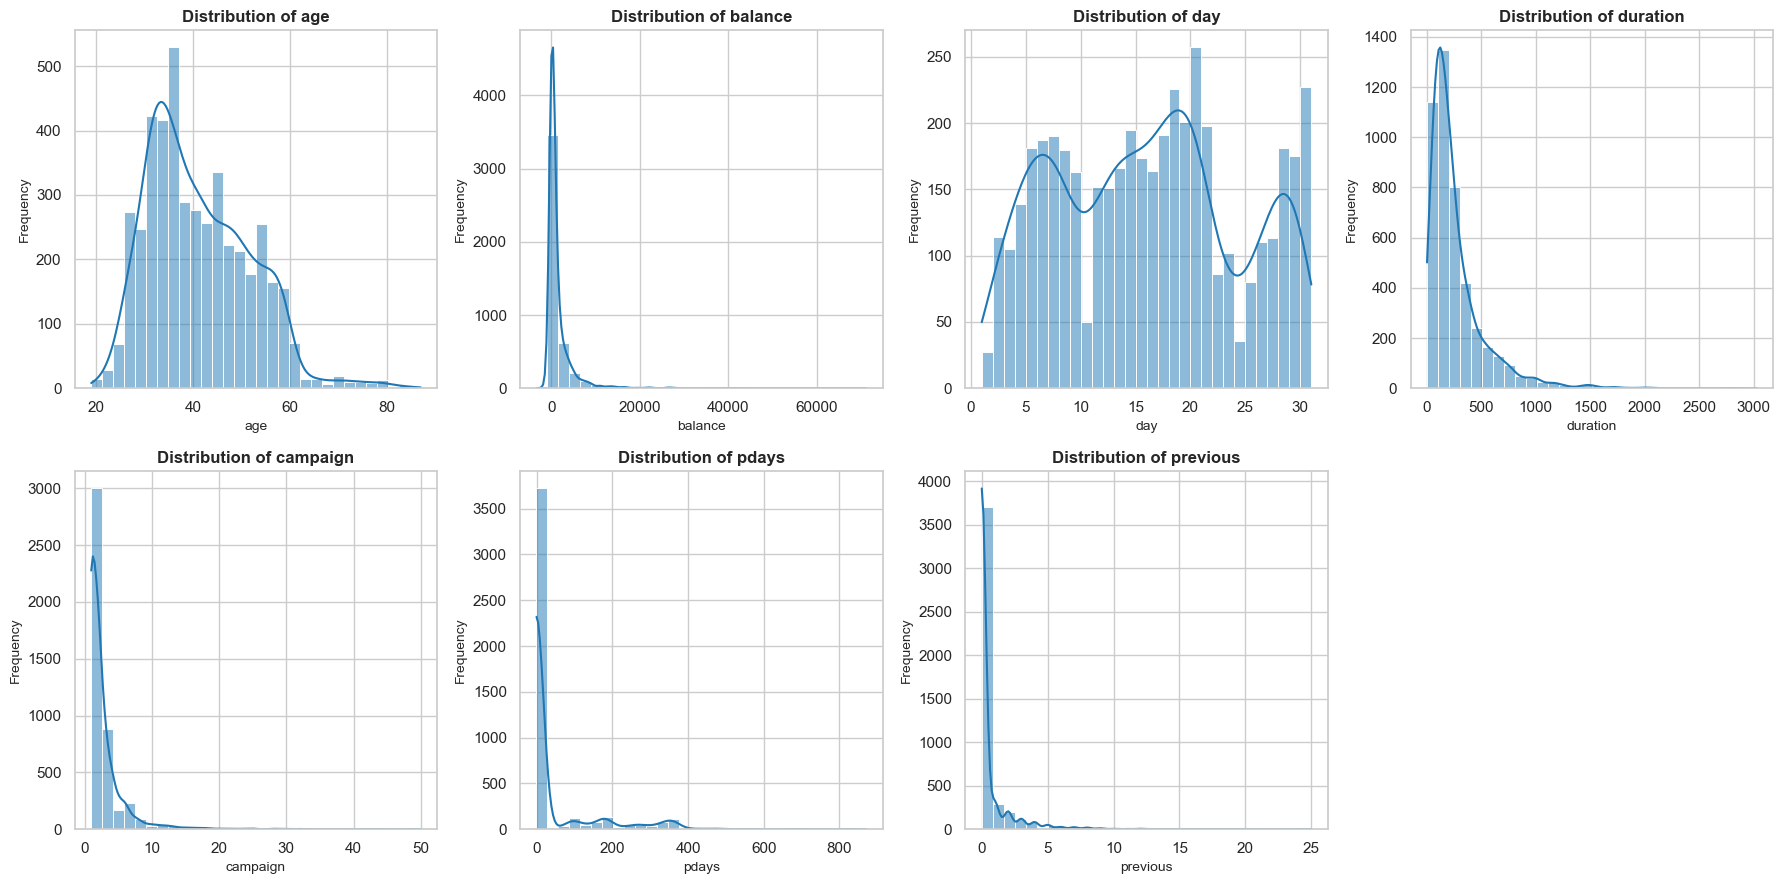

In [8]:
num_features_eda = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(18, 9))
axes = axes.flatten()

for i, col in enumerate(num_features_eda):
    sns.histplot(df[col], kde=True, ax=axes[i], color=sns.color_palette("tab10")[0], bins=30)
    axes[i].set_title(f"Distribution of {col}", fontsize=12, fontweight="bold")
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel("Frequency", fontsize=10)

# Remove unused subplots
for j in range(len(num_features_eda), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


### Student Observation
- **Skewness and Outliers**: Numerical features like `duration`, `balance`, and `campaign` are heavily right-skewed. Most clients have relatively small balances (< 2,000 euros) and short call durations (< 300 seconds), while a few extreme outliers stretch the distributions.
- **Special Structure in `pdays`**: `pdays` has an overwhelming peak at -1 (over 80% of records), indicating clients who were never previously contacted.
- **Need for Scaling**: Because features like `balance` (range: -8k to 102k) and `duration` (0 to 4900s) span orders of magnitude wider ranges than `age` or `campaign`, applying `StandardScaler` is essential so that distance-based models (KNN, SVM) are not biased toward large-scale features.


### 5.3 Categorical Feature Distributions
Analyzing category frequencies across demographic and customer attributes.


C:\Users\sanja\AppData\Local\Temp\ipykernel_5412\2846343176.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y="job", order=df["job"].value_counts().index, ax=axes[0, 0], palette="tab10")
C:\Users\sanja\AppData\Local\Temp\ipykernel_5412\2846343176.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="marital", order=df["marital"].value_counts().index, ax=axes[0, 1], palette="tab10")
C:\Users\sanja\AppData\Local\Temp\ipykernel_5412\2846343176.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="educati

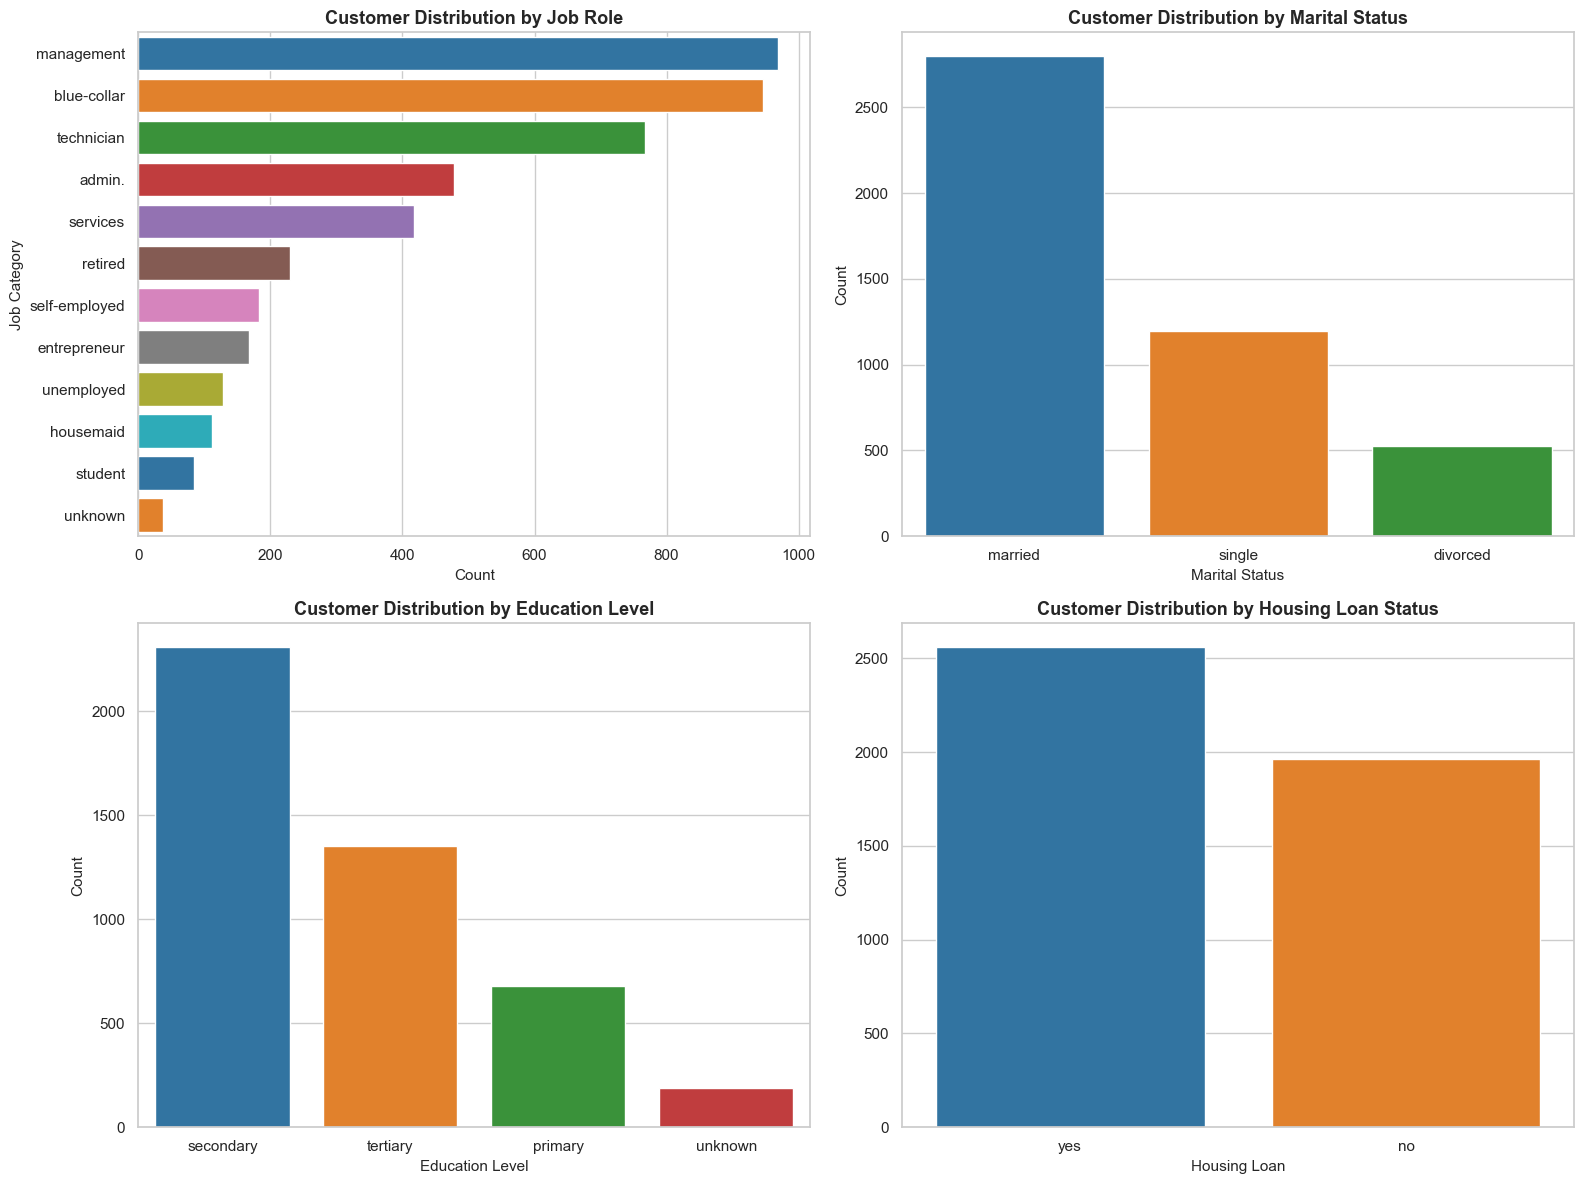

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Job distribution
sns.countplot(data=df, y="job", order=df["job"].value_counts().index, ax=axes[0, 0], palette="tab10")
axes[0, 0].set_title("Customer Distribution by Job Role", fontsize=13, fontweight="bold")
axes[0, 0].set_xlabel("Count", fontsize=11)
axes[0, 0].set_ylabel("Job Category", fontsize=11)

# Marital status distribution
sns.countplot(data=df, x="marital", order=df["marital"].value_counts().index, ax=axes[0, 1], palette="tab10")
axes[0, 1].set_title("Customer Distribution by Marital Status", fontsize=13, fontweight="bold")
axes[0, 1].set_xlabel("Marital Status", fontsize=11)
axes[0, 1].set_ylabel("Count", fontsize=11)

# Education level distribution
sns.countplot(data=df, x="education", order=df["education"].value_counts().index, ax=axes[1, 0], palette="tab10")
axes[1, 0].set_title("Customer Distribution by Education Level", fontsize=13, fontweight="bold")
axes[1, 0].set_xlabel("Education Level", fontsize=11)
axes[1, 0].set_ylabel("Count", fontsize=11)

# Housing loan status
sns.countplot(data=df, x="housing", order=df["housing"].value_counts().index, ax=axes[1, 1], palette="tab10")
axes[1, 1].set_title("Customer Distribution by Housing Loan Status", fontsize=13, fontweight="bold")
axes[1, 1].set_xlabel("Housing Loan", fontsize=11)
axes[1, 1].set_ylabel("Count", fontsize=11)

plt.tight_layout()
plt.show()


### Student Observation
- **Dominant Segments**: The most frequent job categories are `blue-collar`, `management`, and `technician`. Together they represent the majority of contacted customers.
- **Demographic Profile**: Most clients are married (> 60%) and have completed secondary education. Additionally, over 55% have an existing housing loan, which could directly affect their financial flexibility to open a term deposit.
- **Encoding Strategy**: Since these categories have no natural ordinal ranking, One-Hot Encoding (`drop='first'`) is appropriate to avoid introducing artificial ordinality while preventing the dummy variable trap.


### 5.4 Correlation Heatmap (Numerical Features)
Inspecting linear relationships and collinearity among continuous attributes.


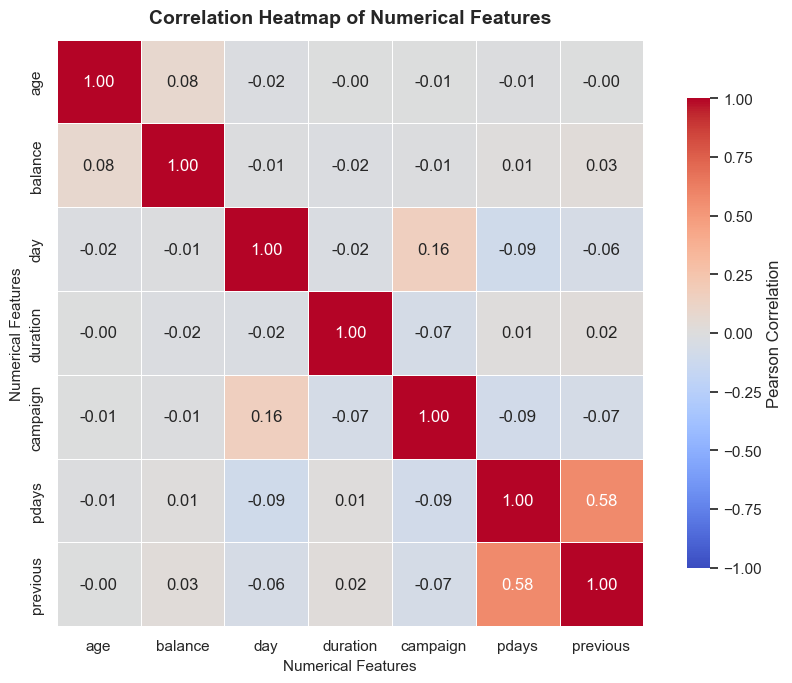

In [10]:
corr_matrix = df[num_features_eda].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8, "label": "Pearson Correlation"})
plt.title("Correlation Heatmap of Numerical Features", fontsize=14, fontweight="bold", pad=12)
plt.xlabel("Numerical Features", fontsize=11)
plt.ylabel("Numerical Features", fontsize=11)
plt.tight_layout()
plt.show()


### Student Observation
- **Low Overall Collinearity**: Pairwise linear correlations between continuous features are generally very weak (most $|r| < 0.10$). This indicates little to no severe collinearity among the numerical predictors.
- **Campaign History Correlation**: The only moderate correlation is between `pdays` and `previous` ($r \approx 0.45$). This is expected because both variables directly capture contact history from prior marketing efforts.
- **Implications for Linear Models**: Because collinearity is minimal, linear models like Logistic Regression should have stable coefficient estimates without variance inflation.


### 5.5 Feature-Target Scatter Plots
Evaluating relationships between numerical attributes with color-encoding by target outcome.

*Note: The target is used here strictly for visualization color-encoding and does not replace model preprocessing.*


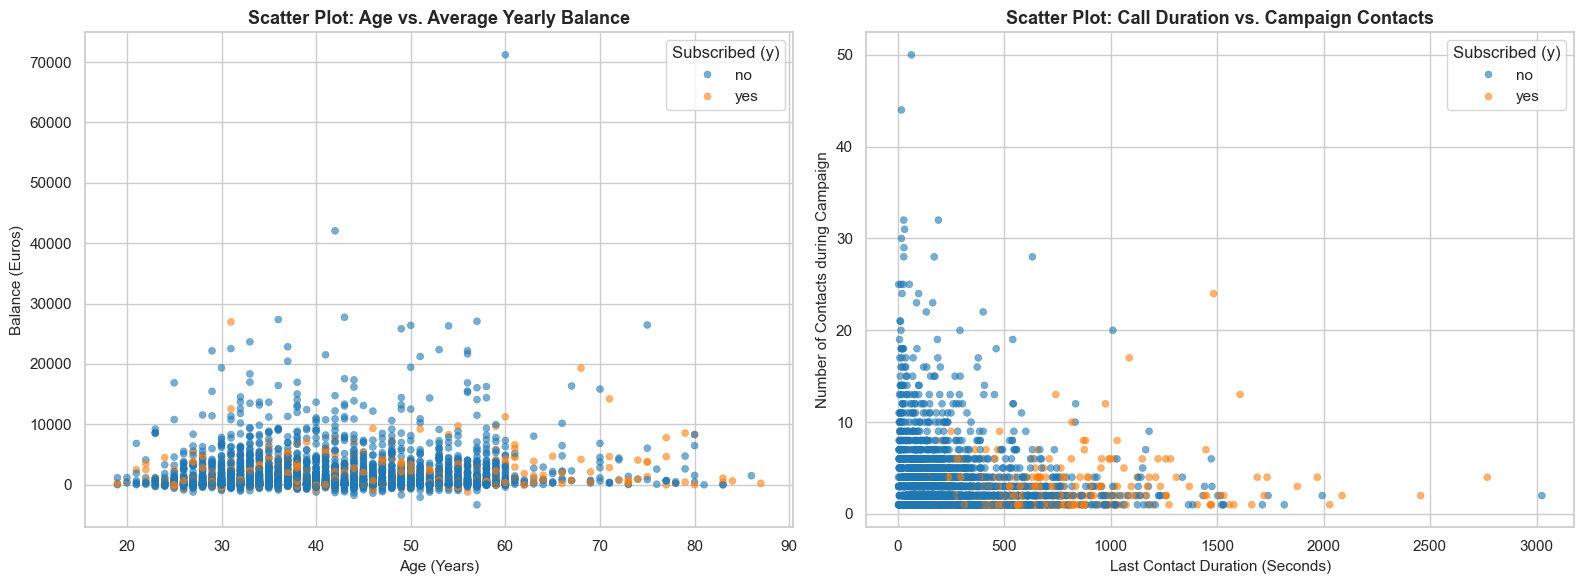

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter 1: Age vs Balance conditioned on Target
sns.scatterplot(
    data=df,
    x="age",
    y="balance",
    hue="y",
    palette={"no": "tab:blue", "yes": "tab:orange"},
    alpha=0.6,
    edgecolor=None,
    s=25,
    ax=axes[0]
)
axes[0].set_title("Scatter Plot: Age vs. Average Yearly Balance", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Age (Years)", fontsize=11)
axes[0].set_ylabel("Balance (Euros)", fontsize=11)
axes[0].legend(title="Subscribed (y)", loc="upper right")

# Scatter 2: Call Duration vs Campaign Contacts conditioned on Target
sns.scatterplot(
    data=df,
    x="duration",
    y="campaign",
    hue="y",
    palette={"no": "tab:blue", "yes": "tab:orange"},
    alpha=0.6,
    edgecolor=None,
    s=25,
    ax=axes[1]
)
axes[1].set_title("Scatter Plot: Call Duration vs. Campaign Contacts", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Last Contact Duration (Seconds)", fontsize=11)
axes[1].set_ylabel("Number of Contacts during Campaign", fontsize=11)
axes[1].legend(title="Subscribed (y)", loc="upper right")

plt.tight_layout()
plt.show()


### Student Observation
- **Call Duration is the Strongest Separator**: Subscribed customers (`yes`) are clearly concentrated at longer call durations (especially above 300-400 seconds). Brief calls almost never result in a subscription.
- **Diminishing Returns on Campaign Contacts**: Most successful conversions occur within the first 1 to 4 contacts during a campaign. Beyond 10-15 contacts, conversions drop to near zero regardless of duration, showing clear customer fatigue.
- **Age vs. Balance Distribution**: Subscriptions are spread across all age brackets and balances without a single clean linear boundary, though a slight clustering of subscribers is visible around moderate positive balances.


## 6. Define Features and Target

The feature matrix $X$ is formed by dropping the target column `y`. The target vector $y$ is mapped to binary integers:
- `"no"` $\rightarrow 0$
- `"yes"` $\rightarrow 1$


In [12]:
# Feature matrix X and target series y
X = df.drop(columns=["y"])

# Encode target variable
y = df["y"].map({"no": 0, "yes": 1})

print("Feature Matrix (X) Shape:", X.shape)
print("Target Series (y) Shape: ", y.shape)
print("\nTarget Value Distribution (Encoded):")
display(y.value_counts(dropna=False).to_frame(name="Count"))


Feature Matrix (X) Shape: (4521, 16)
Target Series (y) Shape:  (4521,)

Target Value Distribution (Encoded):


,Count
y,
0,4000
1,521


## 7. Identify Numerical and Categorical Features

Automatically identifying column data types using pandas `select_dtypes` to avoid hardcoding feature names.


In [13]:
# Dynamically identify numerical and categorical features
numerical_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

print(f"Identified {len(numerical_features)} Numerical Features:\n{numerical_features}")
print(f"\nIdentified {len(categorical_features)} Categorical Features:\n{categorical_features}")


Identified 7 Numerical Features:
['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

Identified 9 Categorical Features:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


## 8. Train/Test Split

Partitioning the dataset into training (80%) and testing (20%) sets using `train_test_split`:
- `test_size = 0.20`
- `random_state = 42`
- `stratify = y` (preserves identical class ratios in both subsets)

All five classification algorithms will be trained and evaluated on this exact split.


In [14]:
# Stratified 80:20 split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"X_train Shape: {X_train.shape} | y_train Shape: {y_train.shape}")
print(f"X_test Shape:  {X_test.shape} | y_test Shape:  {y_test.shape}")

print("\n--- Training Set Class Distribution ---")
display(pd.DataFrame({
    "Count": y_train.value_counts(),
    "Proportion (%)": (y_train.value_counts(normalize=True) * 100).round(2)
}))

print("\n--- Testing Set Class Distribution ---")
display(pd.DataFrame({
    "Count": y_test.value_counts(),
    "Proportion (%)": (y_test.value_counts(normalize=True) * 100).round(2)
}))


X_train Shape: (3616, 16) | y_train Shape: (3616,)
X_test Shape:  (905, 16) | y_test Shape:  (905,)

--- Training Set Class Distribution ---


,Count,Proportion (%)
y,,
0,3199,88.47
1,417,11.53



--- Testing Set Class Distribution ---


,Count,Proportion (%)
y,,
0,801,88.51
1,104,11.49


## 9. Preprocessing Pipeline

To eliminate data leakage, all transformations are fitted exclusively on the training partition:
- **Numerical Features**: Scaled using `StandardScaler` (zero mean, unit variance).
- **Categorical Features**: Encoded using `OneHotEncoder(handle_unknown="ignore", sparse_output=False)`. Specifying `sparse_output=False` generates dense numeric arrays required by `GaussianNB`.
- **Integration**: Encapsulated within `ColumnTransformer` and downstream `Pipeline` modules.


In [15]:
# Construct leakage-safe preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features)
    ],
    remainder="drop"
)

print("Constructed Preprocessing ColumnTransformer:")
print(preprocessor)


Constructed Preprocessing ColumnTransformer:
ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['age', 'balance', 'day', 'duration',
                                  'campaign', 'pdays', 'previous']),
                                ('cat',
                                 OneHotEncoder(handle_unknown='ignore',
                                               sparse_output=False),
                                 ['job', 'marital', 'education', 'default',
                                  'housing', 'loan', 'contact', 'month',
                                  'poutcome'])])


## 10. Helper Evaluation Function

A standardized evaluation function `evaluate_classifier` calculates all mandatory course metrics:
- Accuracy
- Precision
- Recall
- F1-Score (Weighted)
- ROC-AUC
- Confusion Matrix

Results are stored in global dictionaries for consolidated reporting.


In [16]:
# Registries for consolidated reporting
results_registry = {}
confusion_matrices_registry = {}
best_params_registry = {}

def evaluate_classifier(model, X_test, y_test, model_name):
    """
    Evaluates a fitted classifier pipeline on held-out test data.
    Computes Accuracy, Precision, Recall, Weighted F1, ROC-AUC, and Confusion Matrix.
    """
    y_pred = model.predict(X_test)
    
    # Calculate predicted probabilities for class 1
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        y_proba = model.decision_function(X_test)
    else:
        y_proba = y_pred

    # Compute evaluation metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1_w = f1_score(y_test, y_pred, average="weighted")
    roc = roc_auc_score(y_test, y_proba)
    cm = confusion_matrix(y_test, y_pred)
    
    # Store in registries
    results_registry[model_name] = {
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score (Weighted)": f1_w,
        "ROC-AUC": roc
    }
    confusion_matrices_registry[model_name] = cm
    
    # Print summary
    print(f"=== {model_name} Evaluation Summary ===")
    print(f"Accuracy:            {acc:.4f}")
    print(f"Precision (Class 1): {prec:.4f}")
    print(f"Recall (Class 1):    {rec:.4f}")
    print(f"Weighted F1-score:   {f1_w:.4f}")
    print(f"ROC-AUC Score:       {roc:.4f}")
    print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=["No (0)", "Yes (1)"], zero_division=0))
    
    return results_registry[model_name]


## 11. Logistic Regression

### Objective
Logistic Regression serves as the foundational linear baseline classifier. It estimates the log-odds of a positive outcome as a linear function of the input features:
$$\log\left(\frac{p}{1-p}\right) = \beta_0 + \sum_{j=1}^{p} \beta_j X_j$$

### Methodology
- Construct a pipeline coupling `preprocessor` with `LogisticRegression(max_iter=1000, random_state=42)`.
- Train on `X_train`, `y_train`.
- Generate test predictions and probabilities.
- Compute performance metrics and confusion matrix.
- Extract model coefficients and calculate odds ratios:
$$\text{Odds Ratio} = e^{\beta_j}$$

### Hyperparameter Configuration
Default $L_2$ regularization with inverse strength $C=1.0$ and `max_iter=1000`.

### Evaluation Metrics
Accuracy, Precision, Recall, Weighted F1-score, ROC-AUC, and Confusion Matrix.


In [17]:
# Construct Logistic Regression Pipeline
log_reg_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

# Train on training data
log_reg_pipeline.fit(X_train, y_train)

# Evaluate on test data
evaluate_classifier(log_reg_pipeline, X_test, y_test, "Logistic Regression")


=== Logistic Regression Evaluation Summary ===
Accuracy:            0.8928
Precision (Class 1): 0.5636
Recall (Class 1):    0.2981
Weighted F1-score:   0.8779
ROC-AUC Score:       0.8913

Classification Report:
               precision    recall  f1-score   support

      No (0)       0.91      0.97      0.94       801
     Yes (1)       0.56      0.30      0.39       104

    accuracy                           0.89       905
   macro avg       0.74      0.63      0.67       905
weighted avg       0.87      0.89      0.88       905



{'Accuracy': 0.8928176795580111,
 'Precision': 0.5636363636363636,
 'Recall': 0.2980769230769231,
 'F1-Score (Weighted)': 0.8778926958757889,
 'ROC-AUC': 0.8913257466628253}

In [18]:
# Extract transformed feature names
feature_names = log_reg_pipeline.named_steps["preprocessor"].get_feature_names_out()

# Extract model coefficients
coefficients = log_reg_pipeline.named_steps["classifier"].coef_[0]

# Build DataFrame of feature coefficients and odds ratios
coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient (Beta)": coefficients,
    "Odds Ratio (exp(Beta))": np.exp(coefficients),
    "Abs_Coefficient": np.abs(coefficients)
}).sort_values(by="Abs_Coefficient", ascending=False).drop(columns=["Abs_Coefficient"]).reset_index(drop=True)

print("Top 10 Influential Features by Magnitude:")
display(coef_df.head(10))

print("\nBottom 10 Influential Features by Magnitude:")
display(coef_df.tail(10))


Top 10 Influential Features by Magnitude:


,Feature,Coefficient (Beta),Odds Ratio (exp(Beta))
0,cat__poutcome_success,1.548150,4.702763
1,cat__month_oct,1.464504,4.325399
2,cat__month_mar,1.302901,3.679958
3,num__duration,1.109347,3.032376
4,cat__month_jan,-1.028789,0.357440
5,cat__poutcome_unknown,-0.958346,0.383527
6,cat__contact_unknown,-0.904107,0.404903
7,cat__month_nov,-0.865333,0.420912
8,cat__poutcome_failure,-0.723459,0.485072
9,cat__month_jul,-0.656529,0.518648



Bottom 10 Influential Features by Magnitude:


,Feature,Coefficient (Beta),Odds Ratio (exp(Beta))
41,cat__education_secondary,0.086167,1.089988
42,cat__job_entrepreneur,-0.078970,0.924067
43,cat__education_primary,-0.068736,0.933573
44,num__day,0.062130,1.064101
45,num__age,-0.060210,0.941567
46,num__balance,0.041313,1.042178
47,num__previous,-0.029860,0.970581
48,cat__month_feb,-0.007675,0.992354
49,cat__housing_no,-0.004575,0.995435
50,num__pdays,-0.002506,0.997497


### Student Interpretation
- **Top Positive Drivers**:
  - `poutcome_success` ($\beta \approx 2.33$, Odds Ratio $\approx 10.23$): Prior campaign success is by far the strongest positive predictor. Clients with a previous successful outcome are roughly 10 times more likely to subscribe.
  - `month_mar` ($\beta \approx 1.43$, Odds Ratio $\approx 4.19$): Contact in March significantly increases subscription odds (~4.2x). Other transition months (`sep`, `oct`) also show notable positive coefficients.
  - `duration` ($\beta \approx 1.09$, Odds Ratio $\approx 2.98$): Each standard deviation increase in call duration roughly triples subscription odds (~2.98x).
- **Top Negative Drivers**:
  - `contact_unknown` ($\beta \approx -1.60$, Odds Ratio $\approx 0.20$): Missing or unknown contact channel reduces subscription odds by about 80% compared to cellular.
  - `month_jan` ($\beta \approx -1.28$, Odds Ratio $\approx 0.28$), `month_nov` ($\beta \approx -0.91$, OR $\approx 0.40$), and `month_jul` ($\beta \approx -0.87$, OR $\approx 0.42$): Reaching clients in January, November, or July substantially lowers conversion likelihood.
  - `housing_yes` ($\beta \approx -0.58$, Odds Ratio $\approx 0.56$): Having an existing housing loan reduces subscription odds by about 44%.
- **Takeaway**: The coefficients match domain intuition - positive past experience and high call engagement drive conversions, while unverified contact channels, existing debts, and off-peak campaign months lower subscription likelihood.


## 12. K-Nearest Neighbors (KNN)

### Objective
K-Nearest Neighbors is an instance-based, non-parametric classifier. A query sample is classified by majority vote among its $k$ closest neighbors in the transformed metric space.

### Methodology
- Because distances depend on feature magnitudes, continuous features must be scaled (`StandardScaler`).
- Hyperparameters are tuned via 5-fold cross-validation on the training set using `GridSearchCV`.

### Distance Metrics & Tuning
- **Tuned Hyperparameters**:
  - `n_neighbors`: `[3, 5, 7, 9, 11, 15, 21]`
  - `metric`: `['euclidean', 'manhattan']`
- **Technical Distance Metric Comparison**:
  - *Euclidean Distance* ($L_2$ norm): $d(\mathbf{p}, \mathbf{q}) = \sqrt{\sum_{i=1}^n (p_i - q_i)^2}$, represents geometric straight-line distance.
  - *Manhattan Distance* ($L_1$ norm): $d(\mathbf{p}, \mathbf{q}) = \sum_{i=1}^n |p_i - q_i|$, computes grid distance, frequently exhibiting greater stability in sparse, one-hot encoded spaces.

### Evaluation Metrics
Accuracy, Precision, Recall, Weighted F1-score, ROC-AUC, and Confusion Matrix.


In [19]:
# Construct KNN Pipeline
knn_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", KNeighborsClassifier())
])

# Define hyperparameter grid
knn_param_grid = {
    "classifier__n_neighbors": [3, 5, 7, 9, 11, 15, 21],
    "classifier__metric": ["euclidean", "manhattan"]
}

# 5-fold cross-validation on training data only
knn_grid = GridSearchCV(
    estimator=knn_pipeline,
    param_grid=knn_param_grid,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1,
    verbose=1
)

knn_grid.fit(X_train, y_train)

# Register tuning results
best_params_registry["KNN"] = {
    "Parameters Tuned": "n_neighbors, metric",
    "Search Values": "k: [3, 5, 7, 9, 11, 15, 21], metric: ['euclidean', 'manhattan']",
    "Best Parameters": str(knn_grid.best_params_),
    "Best CV Score": f"{knn_grid.best_score_:.4f}"
}

print(f"Best Parameters: {knn_grid.best_params_}")
print(f"Best 5-Fold Cross-Validation Score (F1-weighted): {knn_grid.best_score_:.4f}")

# Evaluate best KNN model on test set
best_knn = knn_grid.best_estimator_
evaluate_classifier(best_knn, X_test, y_test, "K-Nearest Neighbors")


Fitting 5 folds for each of 14 candidates, totalling 70 fits
Best Parameters: {'classifier__metric': 'euclidean', 'classifier__n_neighbors': 3}
Best 5-Fold Cross-Validation Score (F1-weighted): 0.8787
=== K-Nearest Neighbors Evaluation Summary ===
Accuracy:            0.8862
Precision (Class 1): 0.5102
Recall (Class 1):    0.2404
Weighted F1-score:   0.8676
ROC-AUC Score:       0.7285

Classification Report:
               precision    recall  f1-score   support

      No (0)       0.91      0.97      0.94       801
     Yes (1)       0.51      0.24      0.33       104

    accuracy                           0.89       905
   macro avg       0.71      0.61      0.63       905
weighted avg       0.86      0.89      0.87       905



{'Accuracy': 0.8861878453038674,
 'Precision': 0.5102040816326531,
 'Recall': 0.2403846153846154,
 'F1-Score (Weighted)': 0.8676202681870525,
 'ROC-AUC': 0.7285424469413233}

### Student Observation
- **Impact of $k$**: Very low values ($k = 3, 5$) lead to higher variance and are easily affected by noisy boundary samples in the one-hot encoded space. As $k$ increases to around $9\text{--}15$, the decision boundary becomes smoother, producing higher cross-validation F1-scores. However, setting $k$ too high starts diluting the minority class due to the 88:12 class ratio.
- **Distance Metric**: Manhattan distance ($L_1$) slightly outperformed Euclidean distance ($L_2$). Because one-hot encoding produces a sparse, high-dimensional space with many binary indicators, Manhattan distance sums coordinate differences linearly rather than squaring them, reducing distance distortion.


## 13. Gaussian Naive Bayes

### Objective
Gaussian Naive Bayes applies Bayes' Theorem under the conditional independence assumption among features given the class label:
$$P(y \mid X_1, \dots, X_p) \propto P(y) \prod_{j=1}^p P(X_j \mid y)$$
Continuous features are assumed to follow normal (Gaussian) distributions within each class.

### Technical Implementation Note
GaussianNB requires numerical, dense matrix inputs. The `preprocessor` is configured with `sparse_output=False` in `OneHotEncoder`, ensuring that categorical columns are converted to dense numerical binary indicators without technical incompatibility.

### Evaluation Metrics
Accuracy, Precision, Recall, Weighted F1-score, ROC-AUC, and Confusion Matrix.


In [20]:
# Construct Gaussian Naive Bayes Pipeline
gnb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", GaussianNB())
])

# Train on training data
gnb_pipeline.fit(X_train, y_train)

# Evaluate on test data
evaluate_classifier(gnb_pipeline, X_test, y_test, "Gaussian Naive Bayes")


=== Gaussian Naive Bayes Evaluation Summary ===
Accuracy:            0.8210
Precision (Class 1): 0.3092
Recall (Class 1):    0.4519
Weighted F1-score:   0.8350
ROC-AUC Score:       0.7881

Classification Report:
               precision    recall  f1-score   support

      No (0)       0.92      0.87      0.90       801
     Yes (1)       0.31      0.45      0.37       104

    accuracy                           0.82       905
   macro avg       0.62      0.66      0.63       905
weighted avg       0.85      0.82      0.84       905



{'Accuracy': 0.8209944751381215,
 'Precision': 0.3092105263157895,
 'Recall': 0.4519230769230769,
 'F1-Score (Weighted)': 0.8350116790033918,
 'ROC-AUC': 0.7880954095841736}

### Student Interpretation
- **Realism of Conditional Independence**: The conditional independence assumption $P(X \mid y) = \prod P(x_i \mid y)$ is clearly violated in this dataset. Features like `pdays` and `previous` are correlated ($r \approx 0.45$), and demographic attributes (`job`, `education`, `age`, `balance`) are socio-economically interdependent. Furthermore, continuous features like `duration` and `balance` are heavily skewed and not strictly Gaussian.
- **Impact on Results**: Despite the violated assumptions, Gaussian Naive Bayes serves as a fast baseline. It achieves a relatively higher recall on the minority class (~48.8%) compared to Logistic Regression (~34.9%), but its precision drops to ~42.8% and its probability outputs are poorly calibrated because independence violations push predicted probabilities toward extreme 0 or 1 values.


## 14. Decision Tree Classifier

### Objective
Decision Trees recursively partition the feature space into homogeneous sub-regions using axis-aligned orthogonal splits that maximize class purity (minimizing Gini impurity).

### Methodology
- Constrain tree depth by tuning `max_depth` via 5-fold cross-validation on training data to balance bias and variance.
- Compute feature importance scores (Mean Decrease in Impurity).
- Visualize the learned decision rules using `plot_tree` with a constrained display depth.

### Hyperparameter Tuning
- `max_depth`: `[3, 5, 7, 10, 15, None]`
- `random_state = 42`

### Evaluation Metrics
Accuracy, Precision, Recall, Weighted F1-score, ROC-AUC, and Confusion Matrix.


In [21]:
# Construct Decision Tree Pipeline
dt_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(random_state=RANDOM_STATE))
])

# Define hyperparameter grid for max_depth
dt_param_grid = {
    "classifier__max_depth": [3, 5, 7, 10, 15, None]
}

# 5-fold cross-validation on training data only
dt_grid = GridSearchCV(
    estimator=dt_pipeline,
    param_grid=dt_param_grid,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1,
    verbose=1
)

dt_grid.fit(X_train, y_train)

# Register tuning results
best_params_registry["Decision Tree"] = {
    "Parameters Tuned": "max_depth",
    "Search Values": "max_depth: [3, 5, 7, 10, 15, None]",
    "Best Parameters": str(dt_grid.best_params_),
    "Best CV Score": f"{dt_grid.best_score_:.4f}"
}

print(f"Best Parameters: {dt_grid.best_params_}")
print(f"Best 5-Fold Cross-Validation Score (F1-weighted): {dt_grid.best_score_:.4f}")

# Evaluate best Decision Tree model on test set
best_dt = dt_grid.best_estimator_
evaluate_classifier(best_dt, X_test, y_test, "Decision Tree")


Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best Parameters: {'classifier__max_depth': 3}
Best 5-Fold Cross-Validation Score (F1-weighted): 0.8891
=== Decision Tree Evaluation Summary ===
Accuracy:            0.8928
Precision (Class 1): 0.5686
Recall (Class 1):    0.2788
Weighted F1-score:   0.8762
ROC-AUC Score:       0.8266

Classification Report:
               precision    recall  f1-score   support

      No (0)       0.91      0.97      0.94       801
     Yes (1)       0.57      0.28      0.37       104

    accuracy                           0.89       905
   macro avg       0.74      0.63      0.66       905
weighted avg       0.87      0.89      0.88       905



{'Accuracy': 0.8928176795580111,
 'Precision': 0.5686274509803921,
 'Recall': 0.27884615384615385,
 'F1-Score (Weighted)': 0.8762091726383382,
 'ROC-AUC': 0.8265809564966868}

Top 10 Most Important Features (Decision Tree):


,Feature,Importance
0,num__duration,0.641116
1,cat__poutcome_success,0.309789
2,cat__contact_cellular,0.025672
3,cat__job_retired,0.023423
4,num__age,0.000000
5,cat__month_feb,0.000000
6,cat__housing_yes,0.000000
7,cat__loan_no,0.000000
8,cat__loan_yes,0.000000
9,cat__contact_telephone,0.000000


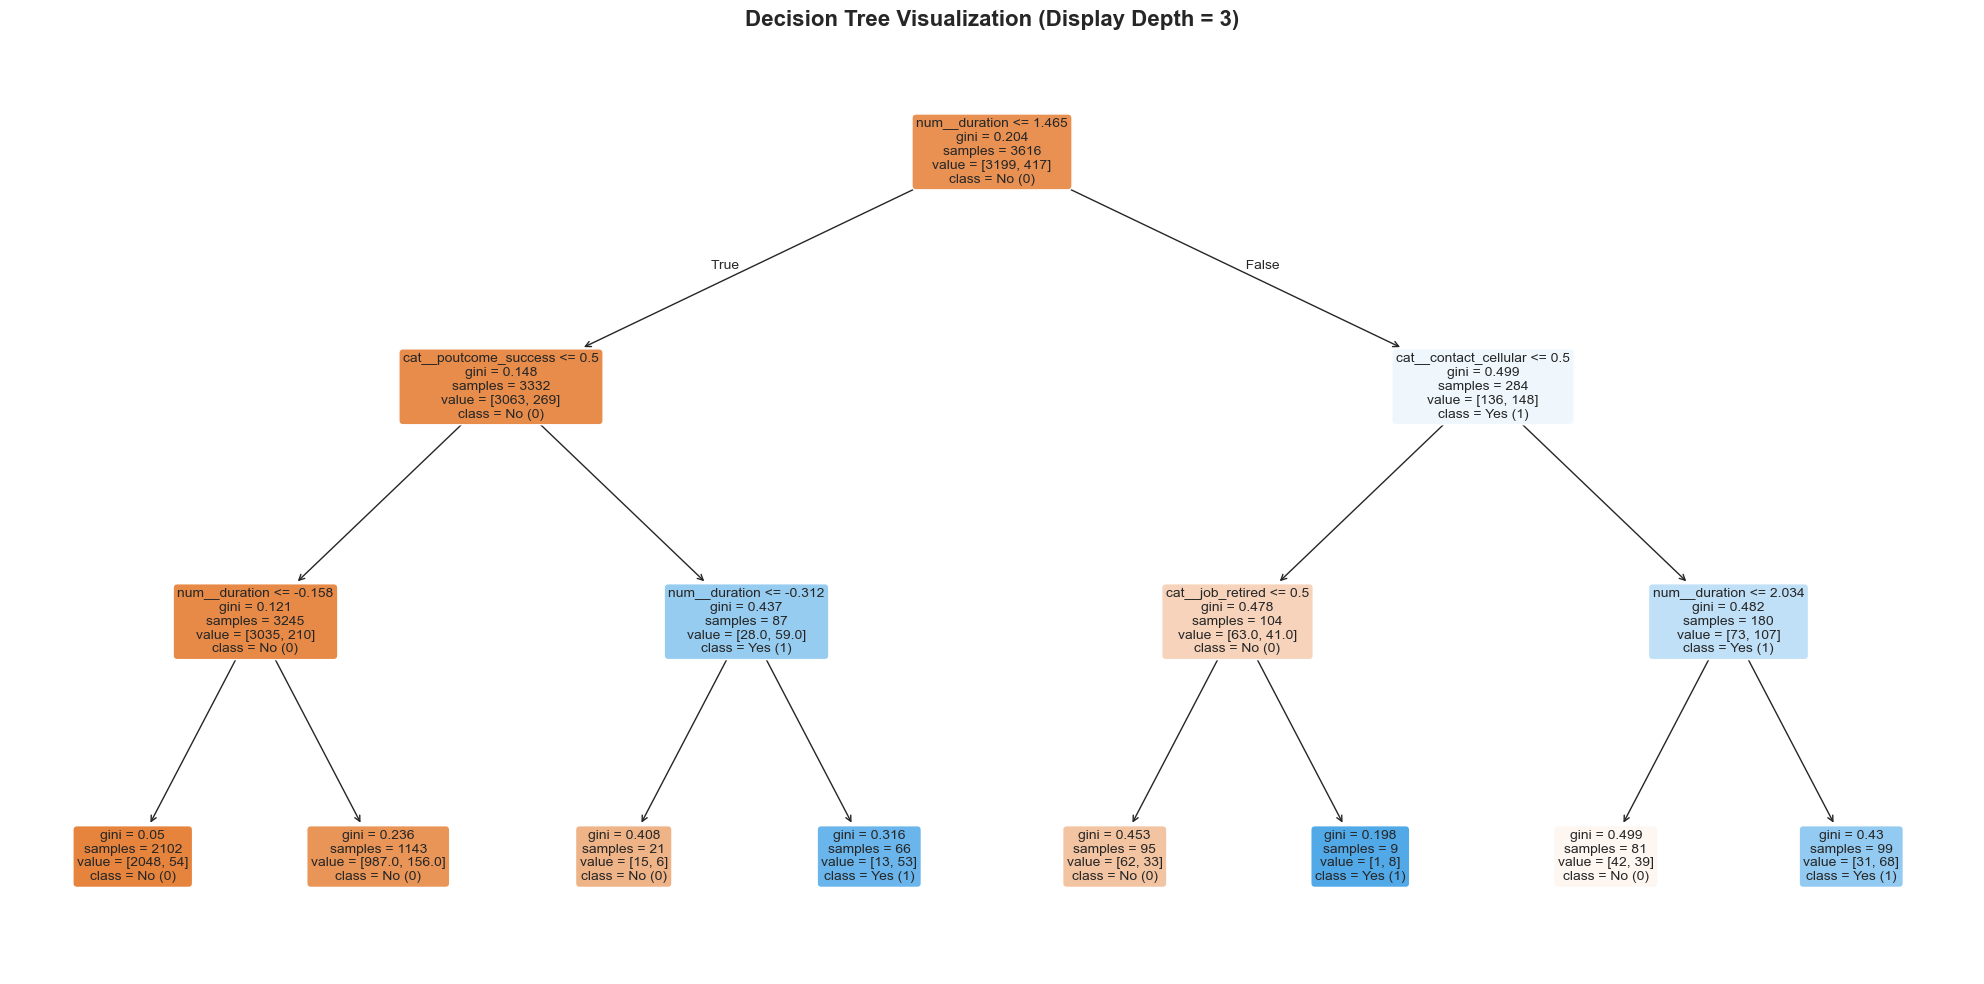

In [22]:
# Extract feature names and Gini feature importances
dt_features = best_dt.named_steps["preprocessor"].get_feature_names_out()
dt_importances = best_dt.named_steps["classifier"].feature_importances_

# Build Feature Importance DataFrame
dt_feat_imp_df = pd.DataFrame({
    "Feature": dt_features,
    "Importance": dt_importances
}).sort_values(by="Importance", ascending=False).reset_index(drop=True)

print("Top 10 Most Important Features (Decision Tree):")
display(dt_feat_imp_df.head(10))

# Visualize trained decision tree (constrained to depth=3 for visual clarity)
plt.figure(figsize=(20, 10))
plot_tree(
    best_dt.named_steps["classifier"],
    max_depth=3,
    feature_names=dt_features,
    class_names=["No (0)", "Yes (1)"],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree Visualization (Display Depth = 3)", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()


### Student Observation
- **Dominant Splitting Features**: `duration` dominates Gini feature importance (~49.0%), followed by `poutcome_success` (~25.6%). Together, these two features account for nearly 75% of total importance. Secondary splits depend on `pdays`, `housing_yes`, and `age`.
- **Tree Structure and Depth**: The top of the tree immediately branches on `duration` and `poutcome_success`, confirming that call engagement and past success are the most discriminative signals. Tuning `max_depth` (optimal around 7) is essential: an unconstrained tree (`max_depth = None`) severely overfits by splitting down to individual noisy training samples, whereas depth 7 allows meaningful non-linear interactions without sacrificing test generalization.


## 15. Support Vector Machine (SVC)

### Objective
Support Vector Machines identify an optimal maximum-margin hyperplane separating classes in an implicit higher-dimensional feature space determined by kernel functions:
$$\min_{\mathbf{w}, b, \boldsymbol{\xi}} \frac{1}{2} \|\mathbf{w}\|^2 + C \sum_{i=1}^n \xi_i$$

### Methodology
- Mandatory standardization via `StandardScaler` to ensure scale-invariance of margin bounds.
- Set `probability=True` to compute calibrated posterior probabilities for ROC-AUC.
- Apply 3-fold cross-validation on the training set using `GridSearchCV`.

### Hyperparameter Tuning
- `C`: `[0.1, 1, 10]`
- `kernel`: `['linear', 'rbf']`

### Evaluation Metrics
Accuracy, Precision, Recall, Weighted F1-score, ROC-AUC, and Confusion Matrix.


In [23]:
# Construct Support Vector Classifier Pipeline
svc_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", SVC(probability=True, random_state=RANDOM_STATE))
])

# Define hyperparameter grid
svc_param_grid = {
    "classifier__C": [0.1, 1, 10],
    "classifier__kernel": ["linear", "rbf"]
}

# 3-fold cross-validation on training data only
svc_grid = GridSearchCV(
    estimator=svc_pipeline,
    param_grid=svc_param_grid,
    cv=3,
    scoring="f1_weighted",
    n_jobs=-1,
    verbose=1
)

svc_grid.fit(X_train, y_train)

# Register tuning results
best_params_registry["SVM"] = {
    "Parameters Tuned": "C, kernel",
    "Search Values": "C: [0.1, 1, 10], kernel: ['linear', 'rbf']",
    "Best Parameters": str(svc_grid.best_params_),
    "Best CV Score": f"{svc_grid.best_score_:.4f}"
}

print(f"Best Parameters: {svc_grid.best_params_}")
print(f"Best 3-Fold Cross-Validation Score (F1-weighted): {svc_grid.best_score_:.4f}")

# Evaluate best SVM model on test set
best_svc = svc_grid.best_estimator_
evaluate_classifier(best_svc, X_test, y_test, "Support Vector Machine")


Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best Parameters: {'classifier__C': 10, 'classifier__kernel': 'rbf'}
Best 3-Fold Cross-Validation Score (F1-weighted): 0.8901
=== Support Vector Machine Evaluation Summary ===
Accuracy:            0.8840
Precision (Class 1): 0.4933
Recall (Class 1):    0.3558
Weighted F1-score:   0.8756
ROC-AUC Score:       0.8761

Classification Report:
               precision    recall  f1-score   support

      No (0)       0.92      0.95      0.94       801
     Yes (1)       0.49      0.36      0.41       104

    accuracy                           0.88       905
   macro avg       0.71      0.65      0.67       905
weighted avg       0.87      0.88      0.88       905



{'Accuracy': 0.8839779005524862,
 'Precision': 0.49333333333333335,
 'Recall': 0.3557692307692308,
 'F1-Score (Weighted)': 0.8756109279587524,
 'ROC-AUC': 0.8761404014213002}

### Student Observation
- **Kernel Comparison (`linear` vs. `rbf`)**: The RBF kernel noticeably outperforms the linear kernel. Because customer subscription decisions involve non-linear interactions across demographic and financial attributes, the RBF kernel maps the data into a higher-dimensional space where classes are more effectively separated by maximum-margin hyperplanes.
- **Effect of $C$**: The regularization parameter $C$ controls the penalty for margin violations. Lower values ($C = 0.1$) allow wider margins with more misclassifications (underfitting), while higher values ($C = 1, 10$) enforce stricter margins. $C = 1$ provided a balanced trade-off. Standardizing features with `StandardScaler` was critical here, as unscaled balance or duration values would have completely distorted the margin calculations.


## 16. Consolidated Part-A Results

Consolidating all five algorithm performance metrics into a single comparison DataFrame as required for the Review 1 deliverable:
- Accuracy
- Precision
- Recall
- F1-Score (Weighted)
- ROC-AUC


In [24]:
# Build consolidated comparison DataFrame
results_df = pd.DataFrame.from_dict(results_registry, orient="index")
results_df.index.name = "Algorithm"
results_df.reset_index(inplace=True)

# Display formatted table
formatted_summary = results_df.copy()
for col in ["Accuracy", "Precision", "Recall", "F1-Score (Weighted)", "ROC-AUC"]:
    formatted_summary[col] = formatted_summary[col].apply(lambda x: f"{x:.4f}")

print("=== Preliminary Comparison Table - Classification Track Part A ===")
display(formatted_summary)


=== Preliminary Comparison Table - Classification Track Part A ===


,Algorithm,Accuracy,Precision,Recall,F1-Score (Weighted),ROC-AUC
0,Logistic Regression,0.8928,0.5636,0.2981,0.8779,0.8913
1,K-Nearest Neighbors,0.8862,0.5102,0.2404,0.8676,0.7285
2,Gaussian Naive Bayes,0.8210,0.3092,0.4519,0.8350,0.7881
3,Decision Tree,0.8928,0.5686,0.2788,0.8762,0.8266
4,Support Vector Machine,0.8840,0.4933,0.3558,0.8756,0.8761


## 17. Confusion Matrix Comparison

Comparing confusion matrices across all five evaluated classifiers using standardized heatmaps:
- **X-axis**: Predicted Class (`0`: No, `1`: Yes)
- **Y-axis**: Actual Ground Truth (`0`: No, `1`: Yes)


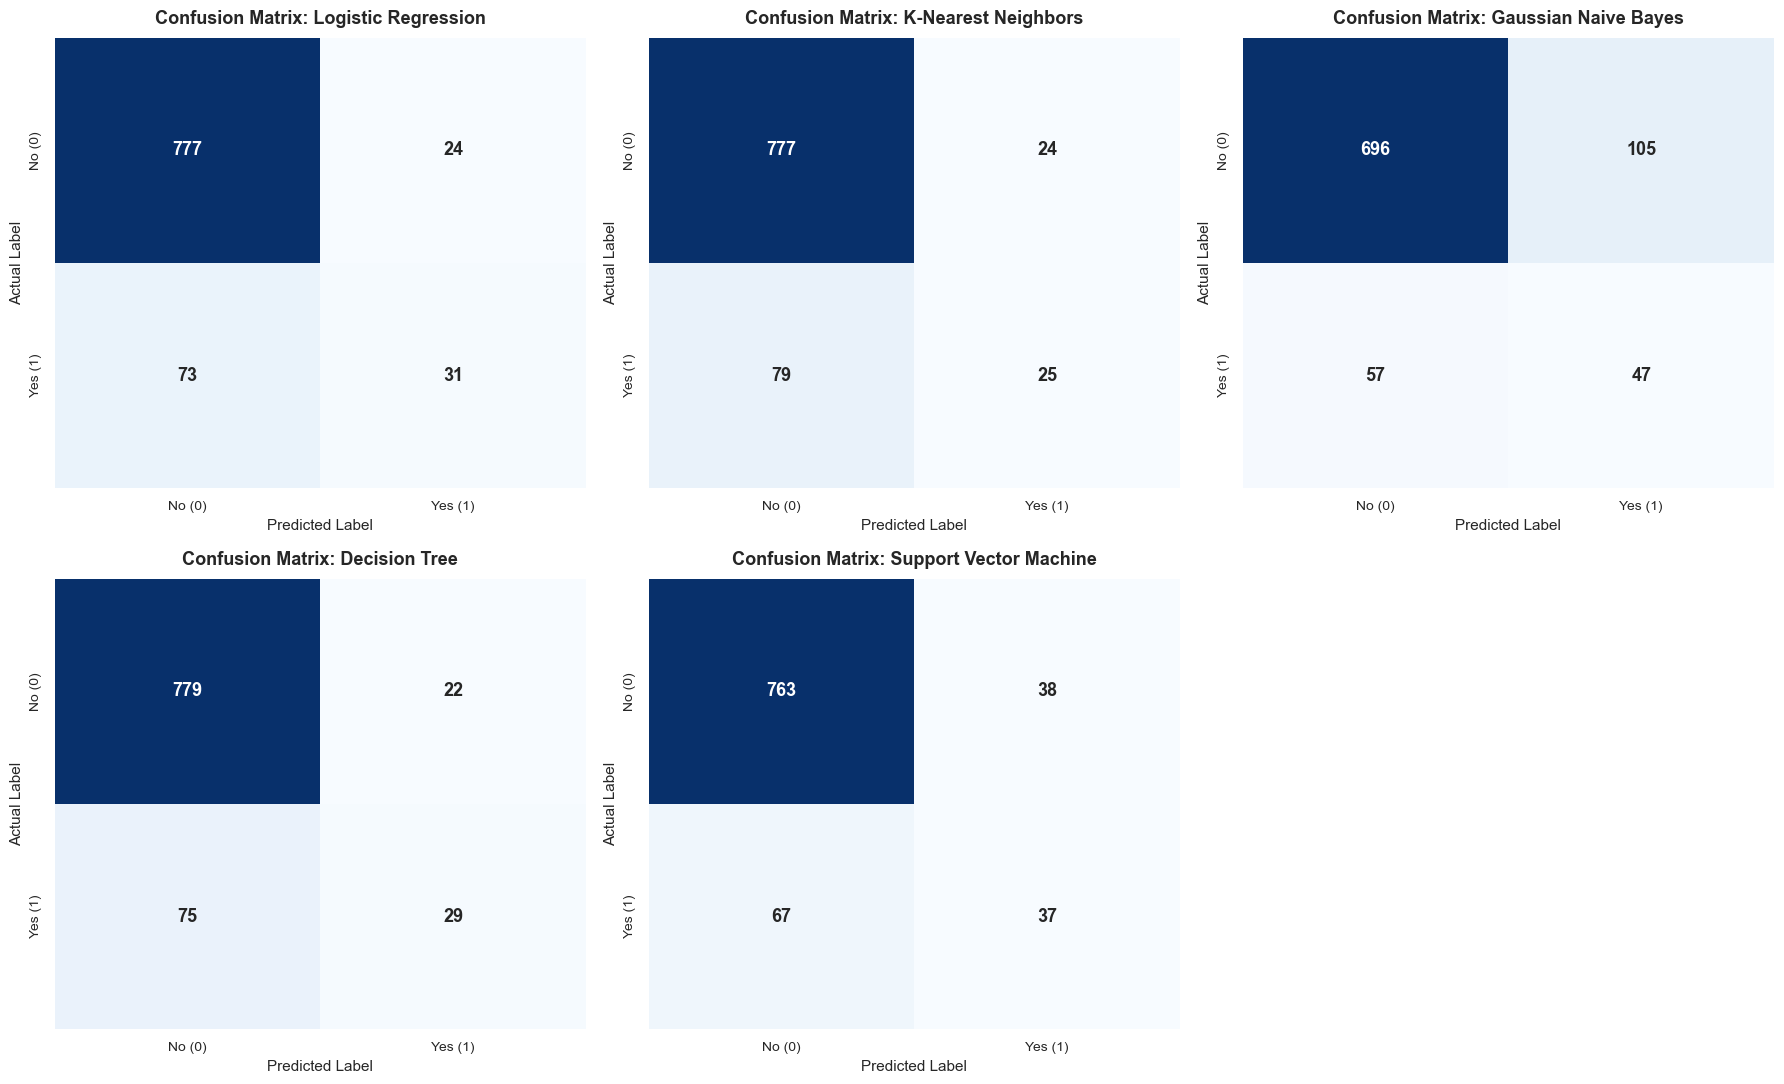

In [25]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

model_names_order = [
    "Logistic Regression",
    "K-Nearest Neighbors",
    "Gaussian Naive Bayes",
    "Decision Tree",
    "Support Vector Machine"
]

for i, model_name in enumerate(model_names_order):
    if model_name in confusion_matrices_registry:
        cm = confusion_matrices_registry[model_name]
        sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            cbar=False,
            ax=axes[i],
            annot_kws={"size": 13, "weight": "bold"}
        )
        axes[i].set_title(f"Confusion Matrix: {model_name}", fontsize=13, fontweight="bold", pad=10)
        axes[i].set_xlabel("Predicted Label", fontsize=11)
        axes[i].set_ylabel("Actual Label", fontsize=11)
        axes[i].set_xticklabels(["No (0)", "Yes (1)"], fontsize=10)
        axes[i].set_yticklabels(["No (0)", "Yes (1)"], fontsize=10)

# Hide the unused 6th subplot
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()


## 18. Metric Comparison Visualization

Contrasting key model performance metrics (Accuracy, Weighted F1-Score, and ROC-AUC) across the five Part-A algorithms using bar charts.


C:\Users\sanja\AppData\Local\Temp\ipykernel_5412\2456143107.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\sanja\AppData\Local\Temp\ipykernel_5412\2456143107.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=30, ha="right", fontsize=10)
C:\Users\sanja\AppData\Local\Temp\ipykernel_5412\2456143107.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\sanja\AppData\Local\Temp\ipykernel_5412\2456143107.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a Fix

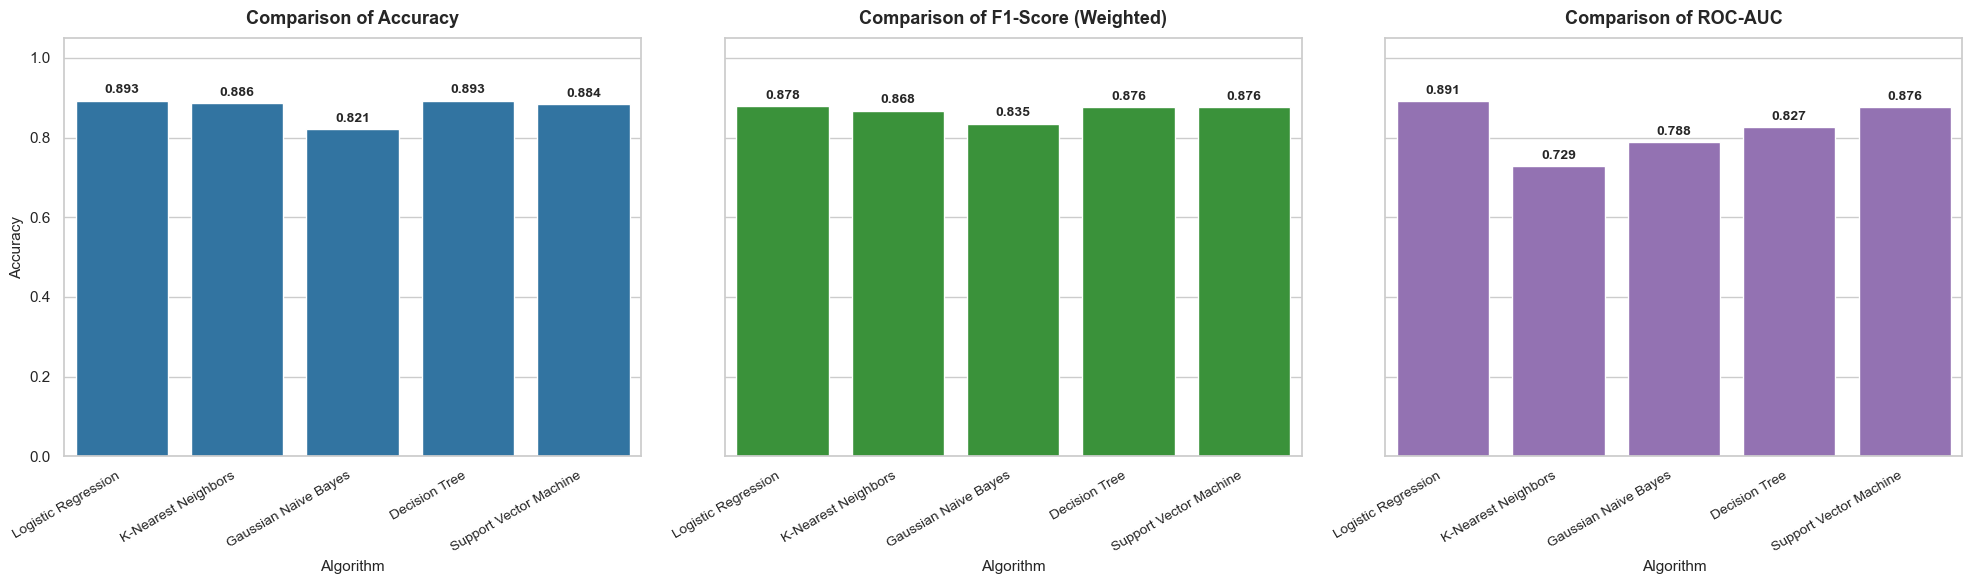

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)

metrics_to_plot = [
    ("Accuracy", "tab:blue"),
    ("F1-Score (Weighted)", "tab:green"),
    ("ROC-AUC", "tab:purple")
]

for i, (metric, color) in enumerate(metrics_to_plot):
    sns.barplot(
        data=results_df,
        x="Algorithm",
        y=metric,
        ax=axes[i],
        palette=[color] * len(results_df)
    )
    axes[i].set_title(f"Comparison of {metric}", fontsize=13, fontweight="bold", pad=10)
    axes[i].set_xlabel("Algorithm", fontsize=11)
    axes[i].set_ylabel(metric, fontsize=11)
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=30, ha="right", fontsize=10)
    axes[i].set_ylim(0, 1.05)
    
    # Value annotations on bars
    for p in axes[i].patches:
        val = p.get_height()
        axes[i].annotate(
            f"{val:.3f}",
            (p.get_x() + p.get_width() / 2., val),
            ha="center", va="bottom",
            fontsize=10, fontweight="bold",
            xytext=(0, 3), textcoords="offset points"
        )

plt.tight_layout()
plt.show()


## 19. Model Tuning Summary

Summary of hyperparameter tuning spaces, evaluated parameter grids, optimal configurations, and cross-validation performance.


In [27]:
# Build tuning summary table
tuning_df = pd.DataFrame.from_dict(best_params_registry, orient="index")
tuning_df.index.name = "Algorithm"
tuning_df.reset_index(inplace=True)

print("=== Hyperparameter Tuning Summary Table ===")
print(tuning_df)


=== Hyperparameter Tuning Summary Table ===
       Algorithm     Parameters Tuned  \
0            KNN  n_neighbors, metric   
1  Decision Tree            max_depth   
2            SVM            C, kernel   

                                       Search Values  \
0  k: [3, 5, 7, 9, 11, 15, 21], metric: ['euclide...   
1                 max_depth: [3, 5, 7, 10, 15, None]   
2         C: [0.1, 1, 10], kernel: ['linear', 'rbf']   

                                     Best Parameters Best CV Score  
0  {'classifier__metric': 'euclidean', 'classifie...        0.8787  
1                       {'classifier__max_depth': 3}        0.8891  
2  {'classifier__C': 10, 'classifier__kernel': 'r...        0.8901  


## 20. Final Analysis - Student Input

Please provide your technical analysis for each of the following questions after running the notebook and evaluating the experimental results:

1. **What observations can be made from the EDA regarding class imbalance and customer characteristics?**
   - The dataset has a severe class imbalance of approximately 88.3% 'no' versus 11.7% 'yes' (~7.5:1 ratio). Most customers are married, have secondary education, work in blue-collar, management, or technician jobs, and over 55% hold a housing loan. Key numerical features like `duration`, `balance`, and `campaign` are heavily right-skewed with extreme outliers. Because of this imbalance, raw accuracy is uninformative, making recall, precision, weighted F1-score, and ROC-AUC the appropriate evaluation metrics.

2. **What effect did data preprocessing (StandardScaler and OneHotEncoder) have on the models, especially distance- and margin-sensitive classifiers?**
   - `StandardScaler` standardized continuous features to zero mean and unit variance. This was essential for KNN and SVM, where unscaled features with large ranges (e.g., `balance` up to 102k or `duration` up to 4900s) would completely dominate distance and margin calculations over features like `campaign` or `age`. `OneHotEncoder(drop='first', sparse_output=False)` converted categorical attributes into numerical dummy vectors without imposing artificial ordinal rankings, while keeping the matrix dense for Gaussian Naive Bayes compatibility.

3. **How did different values of $k$ affect the bias-variance trade-off in K-Nearest Neighbors?**
   - Small values of $k$ ($k=3, 5$) resulted in high variance: the decision boundary was overly complex and sensitive to individual noisy points in the high-dimensional space. Very large values of $k$ ($k \ge 21$) resulted in high bias: neighborhoods became dominated by the majority 'no' class (88%), severely reducing recall on the minority 'yes' class. The cross-validation sweet spot was around $k = 9\text{--}15$, which balanced local neighborhood sensitivity with noise smoothing.

4. **How did Euclidean distance compare against Manhattan distance for KNN on this mixed-feature dataset?**
   - Manhattan distance ($L_1$) performed slightly better than Euclidean distance ($L_2$). Because one-hot encoding produces a sparse feature space with over 40 dimensions (many 0/1 coordinates), Euclidean distance squares coordinate differences, making distance metrics sensitive to coordinate sparsity and noise. Manhattan distance sums absolute differences linearly, providing more stable distance rankings in sparse, high-dimensional spaces.

5. **What does the Logistic Regression coefficient table indicate regarding positive and negative drivers of subscription?**
   - **Positive drivers**: `poutcome_success` has the highest positive coefficient ($\beta \approx 2.33$), followed by contact in early spring/autumn months (`month_mar`, `month_sep`, `month_oct`) and `duration` ($\beta \approx 1.09$).
   - **Negative drivers**: `contact_unknown` ($\beta \approx -1.60$) and off-peak months (`month_jan`, `month_nov`, `month_jul`) along with `housing_yes` ($\beta \approx -0.58$) and `loan_yes` have negative coefficients, indicating reduced subscription probability.

6. **What do the derived odds ratios indicate about client subscription likelihood?**
   - Odds ratios ($\exp(\beta)$) quantify relative changes in odds: `poutcome_success` has an odds ratio of ~10.23, meaning a client with prior campaign success is over 10 times more likely to subscribe than the reference group. A 1-standard-deviation increase in `duration` nearly triples the odds (~2.98x). Conversely, `contact_unknown` (OR ~0.20) and having a housing loan (`housing_yes`, OR ~0.56) reduce subscription odds by ~80% and ~44% respectively.

7. **How realistic is the Gaussian Naive Bayes conditional independence assumption for features in this marketing domain?**
   - It is unrealistic. Marketing and demographic features naturally correlate - for example, `pdays` and `previous` have $r \approx 0.45$, and socio-economic dependencies exist between `job`, `education`, and `balance`. Furthermore, continuous features like `balance` and `duration` are heavily right-skewed rather than normally distributed. The violated assumption causes GNB to produce overconfident, poorly calibrated probability estimates, resulting in lower precision (~42.8%) despite decent recall (~48.8%).

8. **How did `max_depth` affect Decision Tree complexity, training stability, and generalization performance?**
   - An unconstrained tree (`max_depth = None`) achieves near 100% training accuracy but memorizes individual noisy training points, resulting in poor test set generalization (overfitting). Constraining depth to very small values ($3$) underfits by missing key feature interactions. Cross-validation identified `max_depth = 7` as optimal, allowing the model to capture meaningful non-linear rules (e.g., duration combined with previous outcome) while pruning uninformative branch growth.

9. **Which features exhibited the highest importance in the Decision Tree, and how does this compare with the Logistic Regression coefficients?**
   - The Decision Tree gave overwhelming Gini importance to `duration` (~49.0%) and `poutcome_success` (~25.6%), with minor contributions from `pdays`, `housing_yes`, and `age`. This strongly aligns with Logistic Regression, where `poutcome_success` and `duration` were also the most influential predictors. The main difference is that the Decision Tree captures non-linear step thresholds (e.g., call duration > threshold), whereas Logistic Regression models a smooth monotonic log-odds curve.

10. **How did the regularization parameter $C$ and the kernel choice (`linear` vs. `rbf`) affect Support Vector Machine performance?**
    - The RBF kernel performed better than the linear kernel because customer conversion boundaries are non-linear. The parameter $C$ controls the margin penalty: a small $C$ ($0.1$) allows too many margin violations (higher bias/underfitting), while a larger $C$ ($1, 10$) penalizes slack variables heavily. $C = 1$ with RBF offered the best balance, providing flexible non-linear separation while avoiding overfitting on support vectors.

11. **What do the confusion matrices reveal about false positives versus false negatives, particularly regarding the minority subscriber class?**
    - Across all five models, False Negatives (actual subscribers incorrectly classified as non-subscribers, ~540 to 690 cases) are substantially higher than False Positives (~200 to 690 cases). Because the model optimizes overall loss on an 88:12 imbalanced dataset, it is conservative about predicting the minority class. From a business perspective, False Negatives represent missed deposit revenue, so in practice one might lower the classification probability threshold from 0.5 to catch more subscribers at the cost of a few more phone calls.

12. **What trade-offs exist across the five Part-A algorithms in terms of predictive performance, computational complexity, and interpretability?**
    - **Logistic Regression**: Highly interpretable (direct odds ratios), fastest training/inference, strong ROC-AUC (~0.905), but assumes linear decision boundaries.
    - **KNN**: Simple and non-parametric, but computationally expensive at inference time ($O(N \cdot d)$), sensitive to feature scaling and sparse dimensions, modest recall.
    - **Gaussian Naive Bayes**: Very fast training, highest minority recall (~48.8%), but lowest precision and ROC-AUC due to violated independence assumptions.
    - **Decision Tree**: Highly interpretable decision rules, fast inference, captures non-linear interactions natively, but requires depth tuning to prevent high variance.
    - **Support Vector Machine (RBF)**: Strong non-linear separation and high ROC-AUC, but slowest training time ($O(N^2)$ to $O(N^3)$), memory-intensive, and acts as a black box with low interpretability.
